In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy as sc
import xarray as xr
import pandas as pd
import seaborn as sns

plt.rcParams.update({'font.size': 12})

# choose colours
uc = "#298c8c"
cc = "#800074"


In [10]:
# load extracted flashes from both instruments

ubat = xr.open_mfdataset("..\\data\\ubat_extracted_flashes.nc")
cem = xr.open_mfdataset("..\\data\\cem_extracted_flashes.nc")

In [11]:
# remove ubat values that are shallower than cemsor values

# convert to pandas and extract dive numbers
ubat_full = ubat.to_pandas()
cem_full = cem.to_pandas()
dives = ubat_full.dive_num.unique()

ubat_comb = []
cem_comb = []

cem = cem_full.copy()
ubat = ubat_full.copy()

for i in range(len(dives)):
    cem_sel = cem[cem.dive_num==dives[i]]
    cem_sel = cem_sel.dropna(subset='flash_duration')
    min_depth = np.nanmin(cem_sel.depth)

    ubat_sel = ubat[ubat.dive_num==dives[i]]
    ubat_sel = ubat_sel[ubat_sel.depth>=min_depth]
    ubat_sel = ubat_sel.dropna(subset='flash_duration')
    ubat_comb.append(ubat_sel)
    cem_comb.append(cem_sel)
    
ubat = pd.concat(ubat_comb)
cem = pd.concat(cem_comb)


In [12]:
# remove gross outliers larger than 10 seconds

print('number of flashes before removal: %d' % len(ubat_full.flash_duration.values[~np.isnan(ubat_full.flash_duration)]))
ubat_full.loc[ubat_full.flash_duration>10, 'flash_duration'] = np.nan
print('number of flashes after removal: %d' % len(ubat_full.flash_duration.values[~np.isnan(ubat_full.flash_duration)]))

number of flashes before removal: 19961
number of flashes after removal: 19960


In [13]:
# mean duration of all flashes

print('Mean UBAT: %.2f, CEM: %.2f' %(np.nanmean(ubat_full.flash_duration), np.nanmean(cem_full.flash_duration)))
print('Median UBAT: %.2f, CEM: %.2f' %(np.nanmedian(ubat_full.flash_duration), np.nanmedian(cem_full.flash_duration)))
print('Min UBAT: %.2f, CEM: %.2f' %(np.nanmin(ubat_full.flash_duration), np.nanmin(cem_full.flash_duration)))
print('Max UBAT: %.2f, CEM: %.2f' %(np.nanmax(ubat_full.flash_duration), np.nanmax(cem_full.flash_duration)))


Mean UBAT: 0.33, CEM: 0.22
Median UBAT: 0.28, CEM: 0.14
Min UBAT: 0.05, CEM: 0.01
Max UBAT: 4.41, CEM: 2.08


In [14]:
# for the purpose of plotting, remove flashes longer than 3 seconds

print('number of flashes before removal: %d' % len(ubat_full.flash_duration.values[~np.isnan(ubat_full.flash_duration)]))
ubat_full.loc[ubat_full.flash_duration>3, 'flash_duration'] = np.nan
print('number of flashes after removal: %d' % len(ubat_full.flash_duration.values[~np.isnan(ubat_full.flash_duration)]))


number of flashes before removal: 19960
number of flashes after removal: 19937


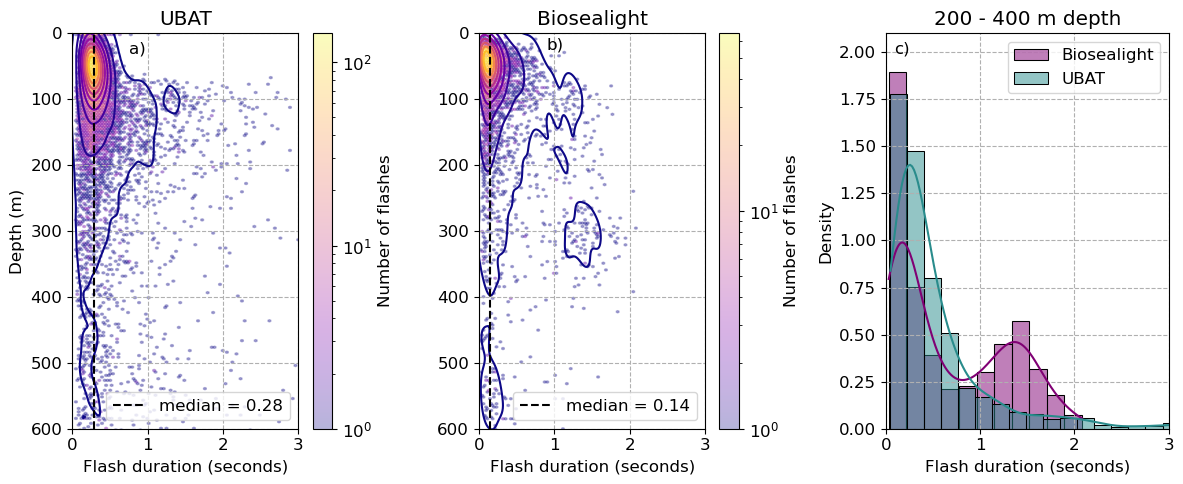

In [17]:
# plot flash duration distribution

fig, ax = plt.subplots(1,3, figsize=(12,5), sharex=True)

im = ax[0].hexbin(ubat.flash_duration, ubat.depth, gridsize=(120,120), bins='log', cmap='plasma', alpha=0.3)
im2 = ax[1].hexbin(cem.flash_duration, cem.depth, gridsize=(60,120), bins='log', cmap='plasma', alpha=0.3)
sns.kdeplot(x=ubat.flash_duration.values, y=ubat.depth.values, cmap='plasma', ax=ax[0])
sns.kdeplot(x=cem.flash_duration.values, y=cem.depth.values, cmap='plasma', ax=ax[1])

cbar = plt.colorbar(im, ax=ax[0], label='Number of flashes')
cbar = plt.colorbar(im2, ax=ax[1], label='Number of flashes')

ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('Flash duration (seconds)')
ax[1].set_xlabel('Flash duration (seconds)')

ax[0].set_title('UBAT')
ax[1].set_title('Biosealight')

for i in range(2):
    ax[i].grid(ls='--', zorder=10)
    ax[i].invert_yaxis()


# plot histogram of flash durations between 200 and 400 m depth
top = 200
bottom = 400

u1_sel = ubat[(ubat.depth>top) & (ubat.depth<=bottom)]
c1_sel = cem[(cem.depth>top) & (cem.depth<=bottom)]

sns.histplot(c1_sel.flash_duration, bins=11, kde=True,stat='density', common_norm=True, color=cc, ax=ax[2], label='Biosealight')
sns.histplot(u1_sel.flash_duration, bins=23, kde=True, stat='density', common_norm=True, color=uc, ax=ax[2], label='UBAT')
ax[2].set_xlabel('Flash duration (seconds)')

ax[2].set_title("200 - 400 m depth")
ax[2].legend()
ax[2].grid(ls='--', zorder=10)

ax[0].text(0.25,0.95, 'a)', transform=ax[0].transAxes)
ax[1].text(0.3,0.96, 'b)', transform=ax[1].transAxes)
ax[2].text(0.03,0.95, 'c)', transform=ax[2].transAxes)

ax[0].axvline(np.nanmedian(ubat.flash_duration), c='k', ls='--', label='median = %.2f' %np.nanmedian(ubat.flash_duration))
ax[1].axvline(np.nanmedian(cem.flash_duration), c='k', ls='--', label='median = %.2f' %np.nanmedian(cem.flash_duration))

ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')


ax[0].set_ylim(600,0)
ax[1].set_ylim(600,0)
ax[0].set_xlim(0,3)
ax[1].set_xlim(0,3)
ax[2].set_ylim(0,2.1)

plt.tight_layout()
plt.show()